# Clase 13: Despliegue

**MDS7202: Laboratorio de Programación Científica para Ciencia de Datos**

**Profesor: Diego Cortez**

## Objetivo

- Conocer diferentes herramientas de despliegue de modelos: `Gradio`, `FastAPI`
- Comprender los distintos componentes de los sistemas basados en ML como la arquitectura cliente-servidor, URL, HTTP, APIs REST, etc...

## Introducción

Hasta ahora nos hemos dedicado a construir modelos: limpiar datos, entrenarlos y evaluar qué tan bien funcionan. Pero una vez que tenemos un modelo guardado en un archivo (.pkl, .joblib, etc.), aparece una pregunta importante: ¿y ahora qué hacemos con él?

Por ejemplo, si tenemos un modelo que predice el valor de una vivienda, podríamos usarlo para procesar un Excel y generar una tabla con predicciones. Pero ¿qué pasa si queremos que una persona ingrese los datos en una página web y obtenga una respuesta al instante? ¿O que otro sistema consulte el modelo automáticamente cada vez que lo necesite? Ahí es donde entra el despliegue (deployment): el conjunto de herramientas y técnicas que permiten convertir un modelo entrenado en algo que otras personas y sistemas puedan utilizar de forma práctica y sencilla.

## Datos de esta clase

Para esta clase, ejemplificaremos lo aprendido utilizando el clásico **Iris Dataset**. El objetivo es simple: entrenar un modelo de ML para clasificar flores del tipo iris en sus 3 categorías: setosa, versicolor y virginica. Las características disponibles son 4: el largo y ancho del pétalo y sépalo.

![Iris Dataset](../../recursos/2024-01/despliegue/images/iris.png)

Comencemos primero importando los datos. Podemos hacer esto de manera simple usando la API de `sklearn`:

In [1]:
from sklearn.datasets import load_iris

iris_df = load_iris(as_frame=True) # cargar dataset
X = iris_df["data"] # features para predecir
y = iris_df["target"] # variable target, 0: setosa, 1: versicolor, 2: viginica

# features disponibles
X 

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [2]:
# variable a predecir
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

Con los datos ya ingestados, podemos entrenar un clasificador de `RandomForest` de manera simple:

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

seed = 3380

# separamos los datos
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, test_size=0.3, random_state = seed)

model = RandomForestClassifier(random_state = seed) # instanciar modelo
model.fit(X_train, y_train) # fit

y_pred = model.predict(X_test) # predict sobre X_test
print(classification_report(y_test, y_pred)) # performance

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.95      1.00      0.97        18
           2       1.00      0.93      0.96        14

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



Genial! Entrenamos efectivamente un modelo de ML para resolver nuestro problema :)

Del entrenamiento, notamos que nuestro modelo tiene una alta capacidad de predicción, acertando el 98% de los casos en el conjunto de test.

## Entrené mi modelo... y ahora qué?

Supongamos que tenemos un cercano (jefe, colega, mamá, hermano, perro, etc) al que queramos mostrarle el funcionamiento de nuestro modelo. ¿Qué es lo que tendríamos que hacer para lograr esto?

Una primera idea sería mostrarles directamente nuestro código montado en nuestro equipo y mostrar como se ejecuta... aunque esto dificilmente es una solución aceptable en términos profesionales. Para atacar este problema de manera efectiva, nos dedicaremos el resto de la clase a aprender diferentes técnicas de **despliegue** de nuestro modelo.



## Pasos previos

Antes de desplegar el modelo, una buena idea es **re entrenarlo con todos los datos disponibles**. Recuerden que hasta ahora su modelo solo fue entrenado con los datos `X_train`, por lo que si desean llevar su modelo a *producción* deberían llevarlo usando el máximo de datos disponible (siempre y cuando esto sea deseable, porsupuesto). 

Podemos lograr lo anterior de manera simple por medio de:

In [4]:
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Después de entrenar el modelo con todos los datos, podemos ahora serializar nuestro modelo usando la librería `pickle`: 

In [5]:
import pickle

# crear "model.pkl" con nuestro modelo serializado
with open('./model.pkl', 'wb') as file:
    pickle.dump(model, file)

Podemos que nuestro modelo se carga de manera efectiva:

In [6]:
# borramos modelo
del model

# noten como ya no podemos predecir sobre X pues model ya no existe
model.predict(X)

NameError: name 'model' is not defined

In [7]:
# cargamos modelo
with open('model.pkl', 'rb') as file:
    model = pickle.load(file)

# verificamos funcionamiento
model.predict(X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## Esencia del despliegue

<div style="text-align: center;">
<img src='../../recursos/2024-01/despliegue/images/diagrama_despliegue.png' width = 650/>
</div>

Cualquier herramienta de despliegue debería ser capaz de:

0. Cargar nuestro modelo 
1. Recibir nuevos datos (i.e una nueva *fila* de X)
2. Pre procesar los datos de manera adecuada (escalar, transformar a one_hot, crear nuevas features, etc)
3. Generar una predicción sobre los datos procesados
4. Retornar la predicción generada

> **Pregunta:** Qué herramienta aprendida en el curso nos puede ayudar a los pasos 2 y 3?

Veamos como se vería esto de manera conceptual en el código:

In [8]:
import warnings
warnings.filterwarnings("ignore")

# cargar modelo
with open('model.pkl', 'rb') as file:
  model = pickle.load(file)

labels_dict = {0: 'setosa', 1: 'versicolor', 2: 'virginica'} # diccionario de etiquetas
def make_prediction(
  sepal_length: float,
  sepal_width: float,
  petal_length: float,
  petal_width: float
):
  '''
  función que devuelve la predicción del modelo dado un set de atributos
  '''

  # mantener el orden!
  features = [
      [sepal_length, sepal_width, petal_length, petal_width] # obs a predecir, OJO con el orden!! 
  ]
  
  prediction = model.predict(features).item() # generar prediccion
  label = labels_dict[prediction] # transformar a etiqueta

  return label # retornar prediccion

make_prediction(sepal_length=2, sepal_width=1, petal_length=1, petal_width=1)

'setosa'

Noten que si queremos cambiar los atributos de entrada, simplemente debemos cambiar los valores de los parámetros de la función:

In [9]:
make_prediction(sepal_length=5, sepal_width=4, petal_length=5, petal_width=3)

'virginica'

In [10]:
make_prediction(sepal_length=5, sepal_width=3, petal_length=4, petal_width=1)

'versicolor'

**Guardaremos una copia del código que tiene la función make_prediction en el archivo recursos\2026-01\13-Despliegue\make_prediction.py**

## Gradio

*Tutorial basado en https://www.youtube.com/watch?v=97KxA1r184o y https://github.com/gradio-app/gradio/*

![Gradio](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQdC1xNkDaMNEbtQRyupw5v32HSGVA6w0zNjA&s)

[gradio](https://www.gradio.app) es una librería de Python similar a `Streamlit` que permite generar **demos** de manera simple especificando los **componentes** de entrada y salida esperados por tu modelo de machine learning.

¿A qué nos referimos con componentes de entrada y salida? Gradio viene con diferentes componentes para diferentes tipos de modelos de machine learning. Algunos ejemplos:

*   Para un **clasificador de imágenes**, el input esperado es de tipo `Image` y la salida es del tipo `Label`.
*   Para un modelo de **speech recognition**, el input esperado es del tipo `Microphone` (lo que permite al usuario grabar desde el navegador) o `Audio` (lo que permite a los usuarios subir sus propios archivos de audio), mientras que la salida es del tipo `Text`.
* Para un modelo de **questiong answering**, se esperan dos entradas: [`Text`, `Text`], una entrada de texto para el párrafo y otro texto para la pregunta, mientras que la salida es del tipo `Text` para contener la respuesta generada.

Una lista completa de los componentes habilitados se puede encontrar en la [documentación](https://gradio.app/docs/).

Además de los componentes de entrada y salida, Gradio espera un tercer parámetro: **la función de predicción**. Este parámetro puede ser ***cualquier* función regular de Python** que reciba los parámetros correspondientes a los componentes de entrada y retorne una salida congruente con los componentes de salida.

Veamos esto en código!

In [11]:
# Instalamos la librería
!uv add gradio

Resolved 139 packages in 22ms
Audited 132 packages in 595ms


In [12]:
import gradio as gr

demo = gr.Interface(
  fn = make_prediction, # noten como estamos usando la función que generamos anteriormente
  inputs = ["number", "number", "number", "number"], # valores de entrada
  outputs = ["text"]
) # valor de salida

demo.launch(share=True) # share = True: nos permite compartir el demo con quien queramos!

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://4e9cc330e7b6684ed1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [13]:
demo.close()

Closing server running on port: 7860


Genial! Ahora que tenemos una primera versión, veamos como podemos mejorarla un poco en términos estéticos:

In [14]:
demo = gr.Interface(
  fn = make_prediction,
  inputs = [ # definimos el intervalo y asignamos un nombre a cada input
      gr.Slider(label = 'Sepal Length', minimum = 0, maximum = 10),
      gr.Slider(label = 'Sepal Width', minimum = 0, maximum = 10), 
      gr.Slider(label = 'Petal Length', minimum = 0, maximum = 10), 
      gr.Slider(label = 'Petal Width', minimum = 0, maximum = 10)],
  outputs = gr.Text(label = 'Predicted Label'), # se define un nombre para la salida
  title = 'Iris ML Demo', # asignar un titulo al demo
  examples=[[0.5, 1.5, 2.5, 3.5], [1, 3, 5, 7]], # generar ejemplos
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [15]:
demo.close()

Closing server running on port: 7860


Genial! Revisemos ahora como customizar aun más el *display* de nuestra aplicación mediante `gr.Blocks`:

In [16]:
with gr.Blocks(theme = gr.themes.Base()) as demo:

  # agregamos un markdown para describir la aplicacion
  gr.Markdown(
  """
  # Iris ML Demo
  Bienvenid@ a Iris ML demo! Esta herramienta esta diseñada para predecir la clase de una flor a partir de sus características usando Machine Learning.
  ## Cómo usar este demo?
  Usar esta herramienta es fácil! Sólo debes seguir los siguientes pasos:
  1. Fijar los valores de **Sepal Length**, **Sepal Width**, **Petal Length** y **Petal Width**.
  2. Observar el tipo de flor que predice el modelo.
  
  Eso es todo! Estás list@ para explorar y predecir diferentes tipos de flores. Que lo disfrutes!
  """)

  # definimos explicitamente la posicion de los elementos
  with gr.Row():
      with gr.Column():
          sepal_length_slider = gr.Slider(label = 'Sepal Length', minimum = 0, maximum = 10)
          sepal_width_slider = gr.Slider(label = 'Sepal Width', minimum = 0, maximum = 10)
          petal_length_slider = gr.Slider(label = 'Petal Length', minimum = 0, maximum = 10)
          petal_width_slider = gr.Slider(label = 'Petal Width', minimum = 0, maximum = 10)

      with gr.Column():
          label = gr.Text(label = 'Predicted Label') # se define un nombre para la salida
  
  with gr.Row():
      button = gr.Button(value = 'Predict!')

  # setear interactividad
  inputs = [sepal_length_slider, sepal_width_slider, petal_length_slider, petal_width_slider]
  outputs = [label]
  button.click(fn = make_prediction, inputs = inputs, outputs = outputs)

  examples = [
      [0.5, 1.5, 2.5, 3.5], # example 1
      [1, 3, 5, 7], # example 2
  ]
  gr.Examples(examples = examples, inputs = inputs) 

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://c2a90f2d8b944540ee.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [17]:
demo.close()

Closing server running on port: 7860


Pueden encontrar la totalidad del código en `recursos/2026-02/13-Despliegue/gradio_app.py`.

**Bonus:** [Tutorial para Desplegar su aplicación de gradio en HuggingFace](https://www.youtube.com/watch?v=97KxA1r184o).

## FastAPI

<img src='../../recursos/2024-01/despliegue/images/fastapi.png'/>

La idea de esta sección es que aprendamos a desplegar nuestra solución de ML por medio de una API usando `FastAPI`. Cabe decir que esta es la manera mas usual y "profesional" para desplegar modelos, por lo que es de suma importancia que sepan como realizar este tipo de procedimientos.

Antes de sumergirnos en el código, un poco de contexto:

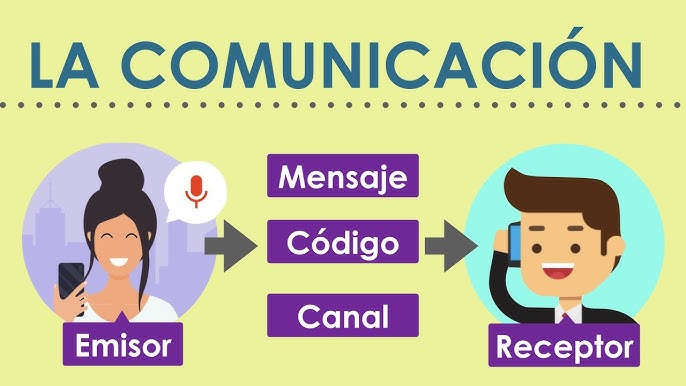

### Arquitectura Cliente-Servidor

Según [Wikipedia](https://es.wikipedia.org/wiki/Cliente-servidor):

> La arquitectura cliente-servidor es un modelo de diseño de software en el que las tareas se reparten entre los proveedores de recursos o servicios, llamados servidores, y los demandantes, llamados clientes. Un cliente realiza peticiones a otro programa, el servidor, quien le da respuesta. 

<div align='center'>
<img alt='Arquitectura Cliente Servidor' src='https://raw.githubusercontent.com/MDS7202/MDS7202/main/recursos/2023-01/27_puesta_en_produccion/cliente_servidor.png' width=800/>
</div>

#### Cliente 

Demanda algún servicio. Sus características principales son:

- Inicia solicitudes (peticiones) y espera respuestas del servidor.
- Puede ser a través de una *interfaz de programación de aplicaciones (API en inglés) o una interfaz gráfica* (como el navegador o un juego ejecutable).

#### Servidor

Provee de servicios. Sus características principales son:

- Reciben las solicitudes de los clientes, las procesan y luego envían una respuesta.
- Pueden aceptar varias solicitudes de distintos clientes a la vez.


### Características de esta arquitectura

Una de las principales ventajas es que permite centralizar la información y las responsabilidades de proveer servicios.
Es decir, solo el servidor será el encargado de manejar las solicitudes, acceder y modificar a las bases de datos, procesar dicha información y responder a sus clientes.


### Opciones y Frameworks

Según [Wikipedia](https://es.wikipedia.org/wiki/Framework): 

> *Framework*: Un entorno de trabajo es un conjunto estandarizado de conceptos, prácticas y criterios para resolver un tipo de problemática particular y que sirve como referencia, para enfrentar y resolver nuevos problemas de índole similar. 

*¡Ya han estado utilizando un framework todo este tiempo!: `scikit-learn` y sus famosos `fit` y `predict`.*


Existe una gigantezca variedad de frameworks (y combinaciones de estos) que implementan esta arquitectura.

##### Servidor (y ocasionalmente también clientes) o *Backend*:

- `Django`
- `Flask`
- `FastAPI`


##### Clientes (Interfaces Gráficas) (la mayoría en JavaScript) o *Frontend*: 

- `React`
- `Vue`


Una combinación de estas tecnologías se denomina *stack tecnológico*.


> **Pregunta**: ¿Conocen alguno de estos? ¿En que consisten?

Visiten los siguientes links para ver buenas comparativas entre estos frameworks: 

- https://www.section.io/engineering-education/choosing-between-django-flask-and-fastapi/
- https://www.analyticsvidhya.com/blog/2020/11/fastapi-the-right-replacement-for-flask/


**En nuestro caso en particular, veremos el framework (de moda) `FastAPI`.**

> **Pregunta:** ¿Qué es una API?

---

### Interfaz de Programación de Aplicaciones / Application Programming Interface (API)

Es un conjunto de reglas, funciones o endpoints que permiten que diferentes aplicaciones interactuen entre sí. Un ejemplo podrían ser las librerías que utilizamos constantemente, en donde un conjunto de funciones se exponen para interactuar con ella.
<div align='center'>
<img src='https://raw.githubusercontent.com/MDS7202/MDS7202/main/recursos/2023-01/27_puesta_en_produccion/pandas_api.png' width=800/>
</div>

<div align='center'>
<p>Ejemplo de una API: la API de pandas</p>
</div>

---

En el caso en particular de los servidores web, la API es el conjunto de funciones (también conocidas como **Endpoints**) que nos permiten interactuar con el servidor. Comunmente esto se hace a través de **URLs** parametrizadas:

<div align='center'>
<img src='https://raw.githubusercontent.com/MDS7202/MDS7202/main/recursos/2023-01/27_puesta_en_produccion/api_maps.png' width=800/>
</div>

<div align='center'>
<img src='https://raw.githubusercontent.com/MDS7202/MDS7202/main/recursos/2023-01/27_puesta_en_produccion/api_maps_2.png' width=800/>
</div>

<div align='center'>
Ejemplo de una web API: La API de <a href='https://developers.google.com/maps/documentation/urls/get-started/'>Google Maps</a>
</div>

#### URL

Una Localizador de recursos uniforme o **Uniform Resource Locator (URL)** es simplemente un localizador de un recurso web más un protocolo que permite acceder a este.

Ejemplo: 

De: https://en.wikipedia.org/wiki/URL

- Protocolo: `https`
- Dirección del recurso: `en.wikipedia.org`
- Archivo: `wiki/URL` (que se interpreta como html)


##### Sintaxis de una URL

<img src='../../recursos/2025-01/13-Despliegue/sinxtaxis_uri.png' />


<div align='center'>
Fuente:  <a href='https://en.wikipedia.org/wiki/URL' />URL en Wikipedia</a>
</div>



#### Protocolo de transferencia de hipertexto o HTTP y HTTPS

[Protocolo de Comunicaciones según Wikipedia](https://es.wikipedia.org/wiki/Protocolo_de_comunicaciones):

> Es un sistema de reglas que permiten que dos o más entidades (computadoras, teléfonos celulares, etc.) de un sistema de comunicación se comuniquen entre ellas con el fin de transmitir información por medio de cualquier tipo de variación de una magnitud física.

> Se trata de las reglas o el estándar que define la sintaxis, semántica y sincronización de la comunicación, así como también los posibles métodos de recuperación de errores


HTTP permite la transmisión de información a través de archivos html y otros formatos.
Esta especifica en los mensajes:

- Cabeceras (Headers) que contienen metadatos.
     - `Host`: Indica el nombre del dominio destino.
     - `User-Agent`: Identifica al cliente que hace la solicitud (navegador, app, etc).
     - `Accept`: Declara qué tipo de contenido espera (`application/json`, `text/html`).
     - `Content-type`: Indica el tipo de dato enviado en el cuerpo (`application/json`, etc).
- Método de petición (`GET`, `POST`, `PUT`, `DELETE`, `HEAD`, `OPTION`, etc...)
     - `GET`: Solicitud para pedir datos.
     - `POST`: Enviar datos (en el cuerpo de la solicitud) comunmente para ser procesados y guardados.
     - `DELETE`: Elimina un dato.
     - `PUT`: Actualiza un dato.


- Códigos de respuesta (https://http.cat/)
  - `1xx` - Respuestas informativas
  - `2xx` - Respuestas satisfactorias 
  - `3xx` - Redirecciones 
  - `4xx` - Errores de los clientes 
  - `5xx` - Errores de los servidores 
  
  
- Cuerpo del mensaje


#### Ejemplo: 

Petición del Cliente:

     GET /index.html HTTP/1.1
     Host: www.example.com
     User-Agent: Mozilla/5.0 (X11; Linux x86_64; rv:45.0) Gecko/20100101 Firefox/45.0
     Accept: text/html


Respuesta del Servidor:

    HTTP/1.1 200 OK
    Date: Fri, 31 Dec 2003 23:59:59 GMT
    Content-Type: text/html
    Content-Length: 1221

    <html lang="eo">
    <head>
    <meta charset="utf-8">
    <title>Título del sitio</title>
    </head>
    <body>
    <h1>Página principal de tuHost</h1>
    (Contenido)
      .
      .
      .
    </body>
    </html>


HTTPS indica que el protocolo es seguro mediante cifrado de la información.

### API REST

Lo último antes de empezar a ver código es hacer una recapitulación de todo lo que hemos visto, lo que puede ser agrupado dentro de un cómodo conjunto de principios llamado **Transferencia de estado representacional o representational state transfer (REST)**.

Según [Wikipedia](https://es.wikipedia.org/wiki/Protocolo_de_transferencia_de_hipertexto), es un conjunto de principios para diseñar aplicaciones web:

- **Un protocolo cliente/servidor sin estado:** cada mensaje HTTP contiene toda la información necesaria para comprender la petición. Como resultado, ni el cliente ni el servidor necesitan recordar ningún estado de las comunicaciones entre mensajes. En la práctica, muchas aplicaciones utilizan cookies y otros mecanismos para mantener el estado de la sesión.

- Posee un conjunto de operaciones bien definidas que se aplican a todos los recursos de información: HTTP en sí define un conjunto pequeño de operaciones, las más importantes son **POST, GET, PUT y DELETE**. Con frecuencia estas operaciones se equiparan a las operaciones **CRUD en bases de datos** (CLAB en castellano: crear,leer,actualizar,borrar) que se requieren para la persistencia de datos.

- **Una sintaxis universal para identificar los recursos.** En un sistema REST, cada recurso es direccionable únicamente a través de su **URI**.

    ``/usuarios``

    ``/usuarios/42``

    ``/productos/15/comentarios``

### Desplegando nuestro modelo con FastAPI

Ya que conocemos lo que es una API REST, revisemos como podemos usar `FastAPI` para implementar nuestra propia API.

[FastAPI](https://fastapi.tiangolo.com) es un framework moderno y de alto rendimiento para construir APIs con Python, que destaca por su simplicidad, rapidez y eficiencia. FastAPI permite desarrollar aplicaciones web rápidamente utilizando la tipificación de Python para generar documentación automática y validaciones de datos sin esfuerzo adicional. Con una curva de aprendizaje amigable, FastAPI es una excelente elección para aprender y dominar el desarrollo de APIs en Python.

Comencemos instalando la libreria:

In [18]:
!uv add fastapi uvicorn

Resolved 139 packages in 1ms
Audited 132 packages in 14ms


Con la libreria instalada, pasemos ahora a escribir nuestra API!

**Nota importante: A diferencia de la sección de `gradio`, será necesario ejecutar nuestro código usando la terminal. Encontrarán el código completo de la API en `recursos/2026-02/13-Despliegue/fastapi_app.py`**

Para usar `fastapi`, lo primero que se debe realizar es generar una instancia del módulo FastAPI:

In [19]:
from fastapi import FastAPI

# crear aplicación
app = FastAPI()

Para levantar nuestra aplicación, tenemos 2 opciones:

1. Escribir en la terminal el siguiente comando:

```{python}
uvicorn nombre_script:app --port 8000
```

2. Adjuntar al final del código de la aplicación el siguiente *chunk*:

```{python}
if __name__ == '__main__':
    uvicorn.run('fastapi_app:app', port = 8000)
```

Luego, la app debería estar disponible en la siguiente ruta: [http://127.0.0.1:8000](http://127.0.0.1:8000)



**Sin embargo**

FastAPI no funciona como gradio que puede desplegarse facilmente desde un notebook. Sí es posible, se debe utilizar herramientas para desacoplar el loop de eventos de jupyter.

La forma más _tradicional_ de realizar esto es poner este código en un **script**, el cual luego se ejecuta con una librería que levante la api, como **uvicorn**

> Nota: No sólo es más tradicional, sino que además es más _productivizable_. Piensen que un servidor no puede estar ejecutando una celda de un notebook para levantar una api, pero sí puede ejecutar un comando de terminal.

Para desplegar nuestra app, crearemos un archivo `despliegue.py` en el cual pondremos el código de la celda anterior. Luego, abrimos una terminal, navegamos a la carpeta donde está `despliegue.py` y ejecutamos:

```bash
uvicorn despliegue:app
```

Recuerden que también la versión final de la app se encuentra en recursos\2025-02\13-Despliegue\fastapi_app.py

Ahora sí, si hicieron todo correctamente, la app debería estar disponible en la siguiente ruta: [http://127.0.0.1:8000](http://127.0.0.1:8000)

> **Pregunta:** ¿Qué les muestra el anterior link? ¿A qué se podría deber esto?

El siguiente paso es crear un *home* o vista default de nuestra aplicación. Usualmente, esta vista está hecha para introducir al usuario al funcionamiento de la aplicación.

Veamos como podemos implementar esto en nuestra aplicación. Remplazamos el código del script por:

In [20]:
from fastapi import FastAPI

app = FastAPI()

@app.get('/') # ruta
async def home(): 
    return {'Hello': 'World'}

Noten como FastAPI hace uso de *decoradores* para definir las rutas de la aplicación (donde en este caso, estamos definiendo un `GET`).

Luego si levantamos nuestra aplicación de nuevo e ingresamos a [http://127.0.0.1:8000](http://127.0.0.1:8000), deberiamos obtener como respuesta:

```{python}
{'Hello': 'World'}
```

> **Pregunta: ¿Qué es un json? ¿Porqué es deseable hacer uso de este tipo en nuestra API?**

Veamos ahora como definir una segunda ruta de acceso. Utilizamos el siguiente código.

In [21]:
from fastapi import FastAPI
# from make_prediction import make_prediction

# init app
app = FastAPI()

# def home
@app.get('/') # ruta
async def home():
    return {'Hello': 'World'}

@app.get('/classroom') # ruta
async def classroom():
    return {'Message': 'This is my first API :)'}

Donde si ingresan a [http://127.0.0.1:8000/classroom](http://127.0.0.1:8000/classroom) deberian observar:

```{python}
{'Message': 'This is my first API :)'}
```

Genial! Ahora que ya sabemos como definir algunas rutas de acceso en nuestra aplicación, veamos como implementar un método `POST` para desplegar nuestro modelo.

> **Pregunta:** ¿Porqué es deseable generar un método `POST` para el despliegue de nuestra solución?

Para que funcione en su script, debe incluir la función `make_prediction`

In [22]:
from fastapi import FastAPI

# init app
app = FastAPI()

# def home
@app.get('/') # ruta
async def home():
    return {'Hello': 'World'}

@app.get('/classroom') # ruta
def classroom():
    return {'Message': 'This is my first API :)'}

# def predict method
@app.post("/predict") # ruta
async def predict(sepal_length: float, sepal_width: float, petal_length: float, petal_width: float): # parametros de entrada

    label = make_prediction(sepal_length, sepal_width, petal_length, petal_width) # generar prediccion

    return {"label": label} # retornar prediccion

Como pueden ver, desplegar nuestra solución fue sumamente simple ya que pudimos reciclar gran parte de lo hecho en `make_prediction`. Probemos ahora nuestra API!

> **Pregunta:** ¿Qué deberia pasar si ingresamos a [http://127.0.0.1:8000/predict](http://127.0.0.1:8000/predict)? ¿Porqué?

Para probar que el método `POST` funciona, `FastAPI` nos habilita la ruta [http://127.0.0.1:8000/docs](http://127.0.0.1:8000/docs) por defecto en donde podemos probar lo que hemos desarrollado en la API.

Veamos ahora en vivo como probar nuestra aplicación!

<p align="center">
  <img src="https://media.tenor.com/ug1DBRF_MjIAAAAC/bill-oreilly-well-do-it-live.gif" width="400">
</p>

Utilizando herramientas como la ruta /docs o postman, se puede probar una api a través de su interfaz gráfica. ¿Pero, qué sucede si eso lo quiero hacer de forma más _programática_? 

Por ejemplo, nuestra aplicación de gradio podría solo ser la interfaz gráfica y no tener el modelo adentro, y simplemente realizar una llamada api a **otro servidor** que expone un endpoint con FastAPI y que realiza las predicciones del modelo.

Esto en realidad es lo que se suele hacer para este tipo de aplicaciones. En este caso, la aplicación queda dividida en 2, donde cada una está disponible en diferentes servidores. Por un lado, la app de gradio maneja la interacción con el usuario, mientras que la app de fastapi maneja las predicciones del modelo y se comunican por HTTPS. 

En este caso, gradio es la parte de "al frente" o **front-end**, mientras que FastAPI sería la parte "de atrás" o **back-end**.

Pero si queremos hacer esto, necesitamos una forma programática de consumir una API. ¿Cuál es el simil de fastapi pero para el cliente?

### Librería requests

La librería `requests` es una de las librerías estandar de python, que permite realizar una petición http (o request) hacia un endpoint. 

In [23]:
import requests

# Realizamos una llamada GET al endpoint classroom
result = requests.get("http://127.0.0.1:8000/classroom")

result

<Response [200]>

El objeto de respuesta tiene toda la información que devuelve la llamada, incluyendo el status code. Para ver el _contenido_ de la respuesta, podemos hacer esto:

In [24]:
result.json()

{'Message': 'This is my first API :)'}

Ahora lo que nos interesa: la llamada al modelo.

In [25]:
result = requests.post(
    url="http://127.0.0.1:8000/predict",
    params={
        "sepal_length": 2.5, "sepal_width": 1.6, "petal_length": 7.5, "petal_width": 4.3
    }
)

result.json()

{'label': 'virginica'}

### Agregarla a gradio

Por último, para tener la historia completa podemos utiliar este recurso en la app de gradio, de forma que el front-end (app de gradio) no incluya el modelo, sino que se comunique con la app del back-end (FastApi) donde sí se encuentra el modelo.

In [26]:
def request_prediction(sepal_length:float, sepal_width:float, petal_length:float, petal_width:float):
    result = requests.post(
        url="http://127.0.0.1:8000/predict",
        params={
            "sepal_length":sepal_length,
            "sepal_width": sepal_width,
            "petal_length": petal_length,
            "petal_width": petal_width
        }
    )

    return result.json()


In [27]:
with gr.Blocks(theme = gr.themes.Base()) as demo:

  # agregamos un markdown para describir la aplicacion
  gr.Markdown(
  """
  # Iris ML Demo
  Bienvenid@ a Iris ML demo! Esta herramienta esta diseñada para predecir la clase de una flor a partir de sus características usando Machine Learning.
  ## Cómo usar este demo?
  Usar esta herramienta es fácil! Sólo debes seguir los siguientes pasos:
  1. Fijar los valores de **Sepal Length**, **Sepal Width**, **Petal Length** y **Petal Width**.
  2. Observar el tipo de flor que predice el modelo.
  
  Eso es todo! Estás list@ para explorar y predecir diferentes tipos de flores. Que lo disfrutes!
  """)

  # definimos explicitamente la posicion de los elementos
  with gr.Row():
      with gr.Column():
          sepal_length_slider = gr.Slider(label = 'Sepal Length', minimum = 0, maximum = 10)
          sepal_width_slider = gr.Slider(label = 'Sepal Width', minimum = 0, maximum = 10)
          petal_length_slider = gr.Slider(label = 'Petal Length', minimum = 0, maximum = 10)
          petal_width_slider = gr.Slider(label = 'Petal Width', minimum = 0, maximum = 10)

      with gr.Column():
          label = gr.Text(label = 'Predicted Label') # se define un nombre para la salida
  
  with gr.Row():
      button = gr.Button(value = 'Predict!')

  # setear interactividad
  inputs = [sepal_length_slider, sepal_width_slider, petal_length_slider, petal_width_slider]
  outputs = [label]
  button.click(fn = request_prediction, inputs = inputs, outputs = outputs)

  examples = [
      [0.5, 1.5, 2.5, 3.5], # example 1
      [1, 3, 5, 7], # example 2
  ]
  gr.Examples(examples = examples, inputs = inputs) 

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://8d5a8192b6d43b778c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


> **❓ Pregunta:** _Ya, pero cómo le envío este endpoint a mi abuelita?_

## Despliegue cloud

Si bien con esto puede haber comunicación entre apps de mi propio computador, habilitar comunicación desde internet es otra cosa. Esto es usualmente lo que queremos, ya que el servidor de predicción suele estar separado de otros servidores que necesiten estas predicciones, y deben ser capaces de comunicarse por internet.

La mejor forma para realizar esto es desplegar en una **nube**, la cual nos disponibiliza un servidor donde se pueden desplegar aplicaciones expuestas (de forma segura) a internet, a cambio de una tarifa. Esto es **servir** una aplicación. Aunque esto no lo veremos en detalle en esta clase ya que es más tema de la siguiente. Sin embargo, es importante recalcar que para realizar esto, la app debe construirse de la forma más replicable posible.

### Replicabilidad

Para el funcionamiento de nuestra app con FastAPI se requiere
- Un modelo ya entrenado guardado en un pickle
- El código que define la función make_prediction y los endpoints de FastAPI.
 
Sin embargo, eso no es todo, ya que ese código se ejecuta en una versión de python específica, con librerías específicas instaladas.

#### Ambientes virtuales

Una primera aproximación para lograr replicabilidad de la app en python es a través de **entornos virtuales**, los cuales pueden ser interpretados como un espacio virtual aislado donde podemos instalar y levantar configuraciones *custom* de nuestro proyecto.

En nuestro proyecto eso ya está configurado a través de **UV**, el cual realiza el manejo de paquetes y también define el ambiente virtual que reune los requisitos para poder ejecutar la app. Así, en el servidor se puede copiar el archivo uv.lock y ejecutar `uv sync` para realizar una copia fidedigna del ambiente que permite ejecutar la app.

#### Contenerización

Sin embargo, incluso con el ambiente y librerías de formas completamente replicables, todavía pueden existir diferencias de funcionamiento a menos que se controlen variables a nivel **sistema operativo**. 

Que la app se ejecute en diferentes sistemas operativos con distintas configuraciones puede llevar a una ejecución distinta del programa, posiblemente debido a dependencia de versiones específicas de programas de sistema, o de drivers, etc.

Esto se refiere definiendo lo necesario para replicar el ambiente completo de ejecución incluso a nivel de sistema operativo mediante **contenerización**, realizado por herramientas como **Docker** que veremos en la próxima clase. Para esto, se genera una "imagen" que es una suerte de "foto" de un sistema operativo.

### Despliegue

Para desplegar nuestro modelo entonces necesitamos 4 cosas:

- Un modelo entrenado
- Código que lo ejecuta
- Definición replicable de ambiente
- Instrucciones de contenerización

Esto en conjunto producirá una **imagen de docker** que luego puede ser fácilmente desplegada en alguna nube. Es más, utilizar este método para desplegar permite probar en local en un ambiente que es idéntico al que se ejecutará en la nube, ayudando a debuggear. 

Todos los proveedores de nubes principales tienen recursos para almacenar y desplegar imagenes, haciéndo esta tarea muy "agnóstica" del proveedor.

<p align="center">
  <img src="https://cdn.prod.website-files.com/69c522edcc0bf2519973c410/69c6485237f58b1b5a5c1076_695918d9d2229b0feea649e1_Taazaa-Blog-Images-1020-x-570-px-7-1.jpeg" width="550">
</p>

A desplegar!

<p align="center">
  <img src="https://media.tenor.com/8XY3bhaDIwsAAAAM/aptos-aptos-meme.gif" width="250">
</p>